# Learning Analytics Model for Ace Learning

This notebook builds a simple, explainable learning analytics workflow for Ace Learning Tuition Centre.

It covers:
- loading the dataset
- feature engineering
- topic mastery calculation
- exam score prediction using Linear Regression
- risk classification using Logistic Regression
- evaluation using RMSE, Accuracy, and F1 Score
- dashboard-ready JSON output for one student


## Cell 1 — Import libraries

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler


## Cell 2 — Load dataset

Make sure your CSV file is stored in `../data/student_learning_data.csv` relative to this notebook.

If your notebook is not inside a `notebooks/` folder, just change the file path below.

In [3]:
df = pd.read_csv('../data/student_learning_data.csv')
df.head()

,student_id,topic,quiz_score,time_taken,attempt_count,past_test_score,time_efficiency,attempt_efficiency,avg_quiz_score_per_topic,topic_mastery,overall_performance_score,final_exam_score,risk_level
0,S001,Statistics,67.45,106.13,3,75.53,0.6355,22.48,44.83,69.10,65.71,73.64,Stable
1,S001,Statistics,38.87,101.92,3,75.53,0.3813,12.96,44.83,49.72,49.45,61.39,Stable
2,S001,Geometry,49.18,120.29,3,75.53,0.4089,16.39,44.63,55.43,55.06,56.69,At Risk
3,S001,Trigonometry,47.13,171.07,2,75.53,0.2755,23.57,42.29,51.74,54.22,63.66,Stable
4,S001,Trigonometry,41.71,138.36,4,75.53,0.3014,10.43,42.29,49.54,50.29,56.18,At Risk


## Cell 3 — Inspect dataset

In [4]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isnull().sum())

print('\nRisk level distribution:')
print(df['risk_level'].value_counts())

Shape: (652, 13)

Columns:
['student_id', 'topic', 'quiz_score', 'time_taken', 'attempt_count', 'past_test_score', 'time_efficiency', 'attempt_efficiency', 'avg_quiz_score_per_topic', 'topic_mastery', 'overall_performance_score', 'final_exam_score', 'risk_level']

Missing values:
student_id                   0
topic                        0
quiz_score                   0
time_taken                   0
attempt_count                0
past_test_score              0
time_efficiency              0
attempt_efficiency           0
avg_quiz_score_per_topic     0
topic_mastery                0
overall_performance_score    0
final_exam_score             0
risk_level                   0
dtype: int64

Risk level distribution:
risk_level
At Risk           409
Stable            226
High Performer     17
Name: count, dtype: int64


## Cell 4 — Feature engineering

We create simple, explainable features:
- `time_efficiency`: higher score achieved in less time
- `attempt_efficiency`: higher score achieved with fewer attempts
- `avg_quiz_score_per_topic`: average quiz score for each topic across all rows


In [5]:
df['time_efficiency'] = df['quiz_score'] / df['time_taken']
df['attempt_efficiency'] = df['quiz_score'] / df['attempt_count']
df['avg_quiz_score_per_topic'] = df.groupby('topic')['quiz_score'].transform('mean')

df[['student_id', 'topic', 'quiz_score', 'time_efficiency', 'attempt_efficiency', 'avg_quiz_score_per_topic']].head()

,student_id,topic,quiz_score,time_efficiency,attempt_efficiency,avg_quiz_score_per_topic
0,S001,Statistics,67.45,0.635541,22.483333,44.834357
1,S001,Statistics,38.87,0.381378,12.956667,44.834357
2,S001,Geometry,49.18,0.408845,16.393333,44.627290
3,S001,Trigonometry,47.13,0.275501,23.565000,42.291855
4,S001,Trigonometry,41.71,0.301460,10.427500,42.291855


## Cell 5 — Calculate topic mastery

We scale time efficiency to a 0–100 style range and then compute a weighted topic mastery score.

Formula:

`topic_mastery = 0.5(quiz_score) + 0.3(past_test_score) + 0.2(time_efficiency_scaled)`

We also flag weak topics where mastery is below 60.

In [6]:
df['time_efficiency_scaled'] = (df['time_efficiency'] / df['time_efficiency'].max()) * 100

df['topic_mastery'] = (
    0.5 * df['quiz_score'] +
    0.3 * df['past_test_score'] +
    0.2 * df['time_efficiency_scaled']
)

df['topic_mastery'] = df['topic_mastery'].clip(0, 100)
df['is_weak_topic'] = df['topic_mastery'] < 60

df[['student_id', 'topic', 'topic_mastery', 'is_weak_topic']].head()

,student_id,topic,topic_mastery,is_weak_topic
0,S001,Statistics,67.253002,False
1,S001,Statistics,48.616303,True
2,S001,Geometry,54.241056,True
3,S001,Trigonometry,50.935611,True
4,S001,Trigonometry,48.669556,True


## Cell 6 — Create overall performance score

In [7]:
df['overall_performance_score'] = (
    0.4 * df['quiz_score'] +
    0.3 * df['past_test_score'] +
    0.2 * df['topic_mastery'] +
    0.1 * df['attempt_efficiency']
)

df[['student_id', 'topic', 'overall_performance_score']].head()

,student_id,topic,overall_performance_score
0,S001,Statistics,65.337934
1,S001,Statistics,49.225927
2,S001,Geometry,54.818544
3,S001,Trigonometry,54.054622
4,S001,Trigonometry,50.119661


## Cell 7 — Define features and targets

We build two targets:
- `y_reg`: final exam score for regression
- `y_cls`: risk level for classification

We do not include `topic` directly in `X` because it is a text column.
For this prototype, the numeric features are enough.

In [8]:
features = [
    'quiz_score',
    'time_taken',
    'attempt_count',
    'past_test_score',
    'time_efficiency',
    'attempt_efficiency',
    'avg_quiz_score_per_topic',
    'topic_mastery',
    'overall_performance_score'
]

X = df[features]
y_reg = df['final_exam_score']
y_cls = df['risk_level']

print('Feature matrix shape:', X.shape)
print('Regression target shape:', y_reg.shape)
print('Classification target shape:', y_cls.shape)

Feature matrix shape: (652, 9)
Regression target shape: (652,)
Classification target shape: (652,)


## Cell 8 — Train/test split for regression

In [9]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print('Regression train shape:', X_train_r.shape)
print('Regression test shape:', X_test_r.shape)

Regression train shape: (521, 9)
Regression test shape: (131, 9)


## Cell 9 — Train/test split for classification

We encode the text labels into numeric labels and use stratified splitting so class proportions stay balanced.

In [10]:
label_encoder = LabelEncoder()
y_cls_encoded = label_encoder.fit_transform(y_cls)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls_encoded, test_size=0.2, random_state=42, stratify=y_cls_encoded
)

print('Classes:', label_encoder.classes_)
print('Classification train shape:', X_train_c.shape)
print('Classification test shape:', X_test_c.shape)

Classes: ['At Risk' 'High Performer' 'Stable']
Classification train shape: (521, 9)
Classification test shape: (131, 9)


## Cell 10 — Scale features for Logistic Regression

Scaling is not essential for Linear Regression here, but it helps Logistic Regression behave more consistently.

In [11]:
scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)


## Cell 11 — Train regression model

In [12]:
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print('RMSE:', round(rmse, 2))

RMSE: 4.13


## Cell 12 — Train classification model

In [13]:
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_c_scaled, y_train_c)

y_pred_c = clf_model.predict(X_test_c_scaled)

accuracy = accuracy_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c, average='weighted')

print('Accuracy:', round(accuracy, 3))
print('Weighted F1 Score:', round(f1, 3))

Accuracy: 0.908
Weighted F1 Score: 0.907


## Cell 13 — Detailed classification evaluation

In [14]:
print(classification_report(y_test_c, y_pred_c, target_names=label_encoder.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test_c, y_pred_c))

                precision    recall  f1-score   support

       At Risk       0.94      0.94      0.94        82
High Performer       1.00      0.50      0.67         4
        Stable       0.85      0.89      0.87        45

      accuracy                           0.91       131
     macro avg       0.93      0.78      0.83       131
  weighted avg       0.91      0.91      0.91       131

Confusion Matrix:
[[77  0  5]
 [ 0  2  2]
 [ 5  0 40]]


## Cell 14 — Regression coefficients

This helps you explain which features influence predicted exam score.

In [15]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': reg_model.coef_
}).sort_values(by='coefficient', ascending=False)

coef_df

,feature,coefficient
0,quiz_score,0.593714
3,past_test_score,0.453294
8,overall_performance_score,0.284212
6,avg_quiz_score_per_topic,0.047228
5,attempt_efficiency,-0.015022
1,time_taken,-0.024509
4,time_efficiency,-0.050967
7,topic_mastery,-0.438797
2,attempt_count,-1.332127


## Cell 15 — Visualise topic mastery for one student

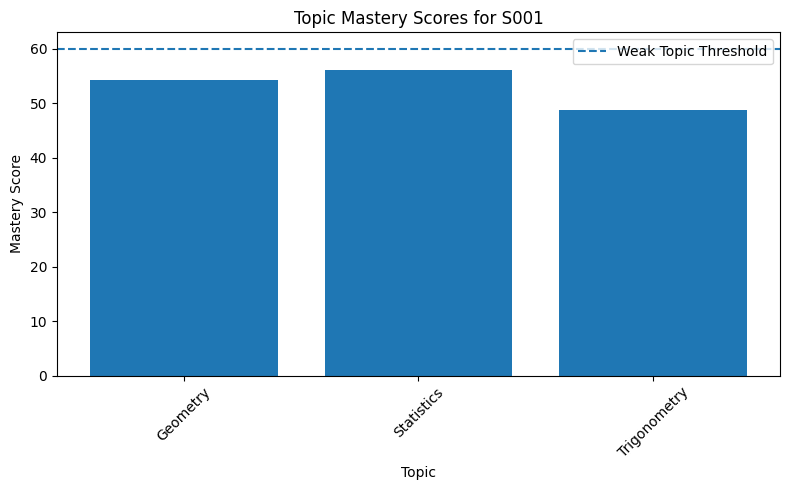

In [16]:
example_student_id = df['student_id'].iloc[0]
student_df = df[df['student_id'] == example_student_id].copy()

topic_mastery_summary = student_df.groupby('topic', as_index=False)['topic_mastery'].mean()

plt.figure(figsize=(8, 5))
plt.bar(topic_mastery_summary['topic'], topic_mastery_summary['topic_mastery'])
plt.axhline(y=60, linestyle='--', label='Weak Topic Threshold')
plt.title(f'Topic Mastery Scores for {example_student_id}')
plt.xlabel('Topic')
plt.ylabel('Mastery Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 16 — Generate dashboard-ready JSON output for one student

In [17]:
student_df = df[df['student_id'] == example_student_id].copy()

# Predicted exam score per row
student_df['predicted_exam_score'] = reg_model.predict(student_df[features])
overall_predicted_exam_score = round(student_df['predicted_exam_score'].mean(), 2)

# Predicted risk level using average feature values for the student
student_avg_features = pd.DataFrame([student_df[features].mean()])
student_avg_features_scaled = scaler.transform(student_avg_features)
predicted_risk_encoded = clf_model.predict(student_avg_features_scaled)[0]
predicted_risk = label_encoder.inverse_transform([predicted_risk_encoded])[0]

# Weak topics list
weak_topics_df = student_df[student_df['is_weak_topic']][['topic', 'topic_mastery']]
weak_topics = [
    {'topic': row['topic'], 'mastery': round(row['topic_mastery'], 2)}
    for _, row in weak_topics_df.iterrows()
]

# Topic mastery list
topic_mastery_list_df = student_df.groupby('topic', as_index=False)['topic_mastery'].mean()
topic_mastery = [
    {'topic': row['topic'], 'score': round(row['topic_mastery'], 2)}
    for _, row in topic_mastery_list_df.iterrows()
]

dashboard_output = {
    'student_id': example_student_id,
    'predicted_exam_score': overall_predicted_exam_score,
    'risk_level': predicted_risk,
    'weak_topics': weak_topics,
    'topic_mastery': topic_mastery
}

print(json.dumps(dashboard_output, indent=2))

{
  "student_id": "S001",
  "predicted_exam_score": 60.93,
  "risk_level": "Stable",
  "weak_topics": [
    {
      "topic": "Statistics",
      "mastery": 48.62
    },
    {
      "topic": "Geometry",
      "mastery": 54.24
    },
    {
      "topic": "Trigonometry",
      "mastery": 50.94
    },
    {
      "topic": "Trigonometry",
      "mastery": 48.67
    },
    {
      "topic": "Trigonometry",
      "mastery": 46.57
    },
    {
      "topic": "Statistics",
      "mastery": 52.28
    }
  ],
  "topic_mastery": [
    {
      "topic": "Geometry",
      "score": 54.24
    },
    {
      "topic": "Statistics",
      "score": 56.05
    },
    {
      "topic": "Trigonometry",
      "score": 48.72
    }
  ]
}


## Cell 17 — Optional save of enriched dataset

This saves the feature-engineered version of the dataset if you want to inspect it later.

In [18]:
# Uncomment to save
# df.to_csv('../data/student_learning_data_enriched.csv', index=False)